# LABORATORIO 03 – REGRESIÓN MULTIVARIABLE Y POLINÓMICA

## Datos de la estudiante

* **Nombre:** Elizabeth Chungara Choque
* **Carrera:** Ingeniería de Sistemas
* **Materia:** Inteligencia Artificial
* **Gestión:** 02/2026
* **Universidad:** Universidad San Francisco Xavier de Chuquisaca

## Dataset utilizado

* **Nombre:** Facebook Comment Volume
* **Fuente:** UCI Machine Learning Repository
* **Archivo utilizado:** `Features_Variant_1.csv`
* **Cantidad de ejemplos:** 40.949
* **Cantidad de características:** 53
* **Variable objetivo:** Número de comentarios que recibirá una publicación de Facebook durante las siguientes \(H\) horas.

## Descripción del laboratorio

El objetivo de este laboratorio es entrenar y evaluar diferentes modelos de regresión para predecir el número futuro de comentarios de una publicación de Facebook.

El dataset contiene información sobre la popularidad de la página, comentarios anteriores, cantidad de veces que una publicación fue compartida, longitud de la publicación, hora y día de publicación, entre otras características.

Para desarrollar el laboratorio se aplicaron los siguientes métodos:

1. Regresión lineal multivariable mediante descenso por gradiente.
2. Regresión polinómica de grado 2.
3. Cálculo de los parámetros theta mediante la ecuación normal.

El dataset fue dividido en un **80% para entrenamiento** y un **20% para validación**. También se aplicó normalización Z-score, se analizaron las correlaciones entre las características y la variable objetivo, y se utilizaron métricas como MAE, MSE, RMSE y \(R^2\).

Finalmente, se compararon los tres modelos y se presentaron 100 predicciones del conjunto de validación para analizar su comportamiento y sus limitaciones.


In [1]:
# ==============================================================================
# LABORATORIO 03 - LIBRERÍAS
# ==============================================================================

import os
import numpy as np
import pandas as pd

from matplotlib import pyplot

# Para reproducir siempre la misma división aleatoria
np.random.seed(42)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ==============================================================================
# CARGA Y AUDITORÍA DEL DATASET FACEBOOK COMMENT VOLUME
# ==============================================================================

# Busca el CSV en la carpeta Datasets o en el directorio actual
if os.path.exists(os.path.join('Datasets', 'Features_Variant_1.csv')):
    ruta_csv = os.path.join('Datasets', 'Features_Variant_1.csv')
else:
    ruta_csv = 'Features_Variant_1.csv'


# Cargar dataset
df = pd.read_csv(ruta_csv, header=None)


# Las primeras 53 columnas son características
X_raw = df.iloc[:, :53].to_numpy(dtype=float)

# La columna 54 es la variable objetivo
y = df.iloc[:, 53].to_numpy(dtype=float)


m = y.shape[0]
n = X_raw.shape[1]


print("=" * 70)
print("       AUDITORÍA DEL DATASET: FACEBOOK COMMENT VOLUME")
print("=" * 70)

print(f"Número de ejemplos (m)              : {m}")
print(f"Número de características (n)       : {n}")
print(f"Valores nulos                       : {df.isnull().sum().sum()}")
print(f"Valores infinitos                   : {np.isinf(X_raw).sum() + np.isinf(y).sum()}")

print("-" * 70)

print(
    f"Variable objetivo y -> "
    f"Min={y.min():.2f}, "
    f"Max={y.max():.2f}, "
    f"Media={y.mean():.2f}"
)

print("-" * 70)

print("¿Cumple m >= 2000? :", m >= 2000)
print("¿Cumple n >= 20?   :", n >= 20)

print("=" * 70)

       AUDITORÍA DEL DATASET: FACEBOOK COMMENT VOLUME
Número de ejemplos (m)              : 40949
Número de características (n)       : 53
Valores nulos                       : 0
Valores infinitos                   : 0
----------------------------------------------------------------------
Variable objetivo y -> Min=0.00, Max=1305.00, Media=7.32
----------------------------------------------------------------------
¿Cumple m >= 2000? : True
¿Cumple n >= 20?   : True


In [3]:
# ==============================================================================
# DIVISIÓN DEL DATASET: 80% ENTRENAMIENTO / 20% VALIDACIÓN
# ==============================================================================

np.random.seed(42)

# Mezclar índices
indices = np.random.permutation(m)

# Punto de división
limite_train = int(0.80 * m)

indices_train = indices[:limite_train]
indices_val = indices[limite_train:]


# Datos de entrenamiento
X_train_raw = X_raw[indices_train]
y_train = y[indices_train]


# Datos de validación
X_val_raw = X_raw[indices_val]
y_val = y[indices_val]


m_train = y_train.shape[0]
m_val = y_val.shape[0]


print("=" * 70)
print("         DIVISIÓN ENTRENAMIENTO / VALIDACIÓN")
print("=" * 70)

print(f"Ejemplos totales        : {m}")
print(f"Entrenamiento (80%)     : {m_train}")
print(f"Validación (20%)        : {m_val}")

print("-" * 70)

print("X_train_raw :", X_train_raw.shape)
print("y_train     :", y_train.shape)
print("X_val_raw   :", X_val_raw.shape)
print("y_val       :", y_val.shape)

print("=" * 70)

         DIVISIÓN ENTRENAMIENTO / VALIDACIÓN
Ejemplos totales        : 40949
Entrenamiento (80%)     : 32759
Validación (20%)        : 8190
----------------------------------------------------------------------
X_train_raw : (32759, 53)
y_train     : (32759,)
X_val_raw   : (8190, 53)
y_val       : (8190,)


In [4]:
# ==============================================================================
# ANÁLISIS DE CORRELACIÓN ENTRE CARACTERÍSTICAS Y VARIABLE OBJETIVO
# ==============================================================================

correlaciones = []

for j in range(X_train_raw.shape[1]):

    # Si una columna es constante, su correlación no está definida
    if np.std(X_train_raw[:, j]) == 0:
        corr = 0.0
    else:
        corr = np.corrcoef(
            X_train_raw[:, j],
            y_train
        )[0, 1]

    correlaciones.append(corr)


correlaciones = np.array(correlaciones)

# Ordenar por valor absoluto de correlación
indices_correlacion = np.argsort(
    np.abs(np.nan_to_num(correlaciones))
)[::-1]


print("=" * 70)
print("    10 CARACTERÍSTICAS CON MAYOR RELACIÓN CON LA ETIQUETA")
print("=" * 70)

for idx in indices_correlacion[:10]:
    print(
        f"Característica X{idx + 1:02d} -> "
        f"correlación = {correlaciones[idx]:.4f}"
    )

print("=" * 70)


# Característica con mayor correlación absoluta
mejor_indice = indices_correlacion[0]

print(
    f"\nCaracterística seleccionada para la gráfica: "
    f"X{mejor_indice + 1}"
)

    10 CARACTERÍSTICAS CON MAYOR RELACIÓN CON LA ETIQUETA
Característica X31 -> correlación = 0.5424
Característica X34 -> correlación = 0.3864
Característica X12 -> correlación = 0.3572
Característica X33 -> correlación = 0.3496
Característica X07 -> correlación = 0.3469
Característica X22 -> correlación = 0.3456
Característica X08 -> correlación = 0.3405
Característica X23 -> correlación = 0.3381
Característica X30 -> correlación = 0.3350
Característica X17 -> correlación = 0.3255

Característica seleccionada para la gráfica: X31


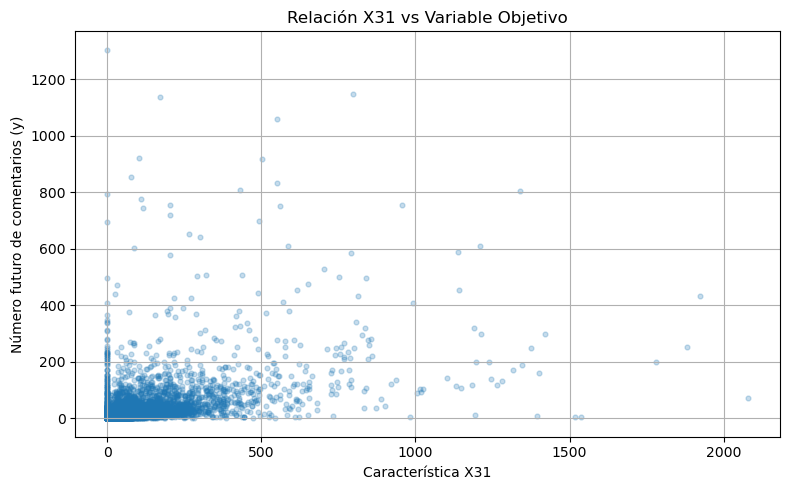

In [5]:
# ==============================================================================
# GRÁFICA DE RELACIÓN ENTRE UNA CARACTERÍSTICA Y LA ETIQUETA
# ==============================================================================

pyplot.figure(figsize=(8, 5))

pyplot.scatter(
    X_train_raw[:, mejor_indice],
    y_train,
    alpha=0.25,
    s=12
)

pyplot.xlabel(
    f'Característica X{mejor_indice + 1}'
)

pyplot.ylabel(
    'Número futuro de comentarios (y)'
)

pyplot.title(
    f'Relación X{mejor_indice + 1} vs Variable Objetivo'
)

pyplot.grid(True)

pyplot.tight_layout()

pyplot.show()

In [6]:
# ==============================================================================
# NORMALIZACIÓN DE CARACTERÍSTICAS MEDIANTE Z-SCORE
# ==============================================================================

def featureNormalize(X):

    X_norm = X.copy()

    # Media de cada característica
    mu = np.mean(X, axis=0)

    # Desviación estándar
    sigma = np.std(X, axis=0)

    # Evitar divisiones entre cero
    sigma[sigma == 0] = 1.0

    # Normalización Z-score
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


print("Función featureNormalize definida correctamente.")

Función featureNormalize definida correctamente.


In [7]:
# ==============================================================================
# PREPARACIÓN DE DATOS - REGRESIÓN LINEAL MULTIVARIABLE
# ==============================================================================

# Normalizar entrenamiento
X_train_norm_lin, mu_lin, sigma_lin = featureNormalize(
    X_train_raw
)


# Validación usa la media y desviación DEL ENTRENAMIENTO
X_val_norm_lin = (
    X_val_raw - mu_lin
) / sigma_lin


# Añadir columna x0 = 1
X_train_lin = np.concatenate(
    [
        np.ones((m_train, 1)),
        X_train_norm_lin
    ],
    axis=1
)


X_val_lin = np.concatenate(
    [
        np.ones((m_val, 1)),
        X_val_norm_lin
    ],
    axis=1
)


print("=" * 70)
print("       PREPARACIÓN - REGRESIÓN LINEAL MULTIVARIABLE")
print("=" * 70)

print("X_train_lin :", X_train_lin.shape)
print("X_val_lin   :", X_val_lin.shape)

print("-" * 70)

print("Primeras 5 medias:")
print(np.round(mu_lin[:5], 4))

print("\nPrimeras 5 desviaciones estándar:")
print(np.round(sigma_lin[:5], 4))

print("=" * 70)

       PREPARACIÓN - REGRESIÓN LINEAL MULTIVARIABLE
X_train_lin : (32759, 54)
X_val_lin   : (8190, 54)
----------------------------------------------------------------------
Primeras 5 medias:
[1.28583899e+06 4.60629590e+03 4.46254577e+04 2.42468000e+01
 1.52440000e+00]

Primeras 5 desviaciones estándar:
[5.76711191e+06 2.03431639e+04 1.03527065e+05 1.99543000e+01
 1.81138000e+01]


In [8]:
# ==============================================================================
# PREPARACIÓN DE DATOS - REGRESIÓN POLINÓMICA GRADO 2
# ==============================================================================

# -----------------------------
# ENTRENAMIENTO
# -----------------------------

X_train_cuadratico = X_train_raw ** 2

X_train_poly_raw = np.concatenate(
    [
        X_train_raw,
        X_train_cuadratico
    ],
    axis=1
)


# -----------------------------
# VALIDACIÓN
# -----------------------------

X_val_cuadratico = X_val_raw ** 2

X_val_poly_raw = np.concatenate(
    [
        X_val_raw,
        X_val_cuadratico
    ],
    axis=1
)


# Normalización calculada SOLO con entrenamiento
X_train_norm_poly, mu_poly, sigma_poly = featureNormalize(
    X_train_poly_raw
)


# Aplicar los mismos parámetros a validación
X_val_norm_poly = (
    X_val_poly_raw - mu_poly
) / sigma_poly


# Añadir x0 = 1
X_train_poly = np.concatenate(
    [
        np.ones((m_train, 1)),
        X_train_norm_poly
    ],
    axis=1
)


X_val_poly = np.concatenate(
    [
        np.ones((m_val, 1)),
        X_val_norm_poly
    ],
    axis=1
)


print("=" * 70)
print("       ESPACIO POLINÓMICO DE GRADO 2")
print("=" * 70)

print(
    "Características originales        :",
    X_train_raw.shape[1]
)

print(
    "Términos cuadrados                :",
    X_train_cuadratico.shape[1]
)

print(
    "Total características polinómicas :",
    X_train_poly_raw.shape[1]
)

print("-" * 70)

print("X_train_poly :", X_train_poly.shape)
print("X_val_poly   :", X_val_poly.shape)

print("=" * 70)

       ESPACIO POLINÓMICO DE GRADO 2
Características originales        : 53
Términos cuadrados                : 53
Total características polinómicas : 106
----------------------------------------------------------------------
X_train_poly : (32759, 107)
X_val_poly   : (8190, 107)


In [9]:
# ==============================================================================
# FUNCIÓN DE COSTO Y DESCENSO POR EL GRADIENTE
# ==============================================================================

def computeCostMulti(X, y, theta):

    m_local = y.shape[0]

    diferencia = np.dot(X, theta) - y

    J = (
        1.0 / (2.0 * m_local)
    ) * np.dot(
        diferencia.T,
        diferencia
    )

    return J



def gradientDescentMulti(
    X,
    y,
    theta,
    alpha,
    num_iters
):

    m_local = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):

        # Error
        diferencia = np.dot(X, theta) - y

        # Gradiente vectorizado
        gradiente = (
            1.0 / m_local
        ) * np.dot(
            X.T,
            diferencia
        )

        # Actualizar parámetros
        theta = theta - alpha * gradiente

        # Guardar costo
        J_history.append(
            computeCostMulti(
                X,
                y,
                theta
            )
        )

    return theta, J_history


print("Funciones de optimización definidas correctamente.")

Funciones de optimización definidas correctamente.


In [10]:
# ==============================================================================
# VERIFICACIÓN DEL COSTO INICIAL
# ==============================================================================

theta_cero_lin = np.zeros(
    X_train_lin.shape[1]
)

theta_cero_poly = np.zeros(
    X_train_poly.shape[1]
)


costo_inicial_lin = computeCostMulti(
    X_train_lin,
    y_train,
    theta_cero_lin
)


costo_inicial_poly = computeCostMulti(
    X_train_poly,
    y_train,
    theta_cero_poly
)


print("=" * 70)
print("             COSTOS INICIALES")
print("=" * 70)

print(
    f"Regresión Lineal     : "
    f"{costo_inicial_lin:.4f}"
)

print(
    f"Regresión Polinómica : "
    f"{costo_inicial_poly:.4f}"
)

print("=" * 70)

             COSTOS INICIALES
Regresión Lineal     : 621.8717
Regresión Polinómica : 621.8717


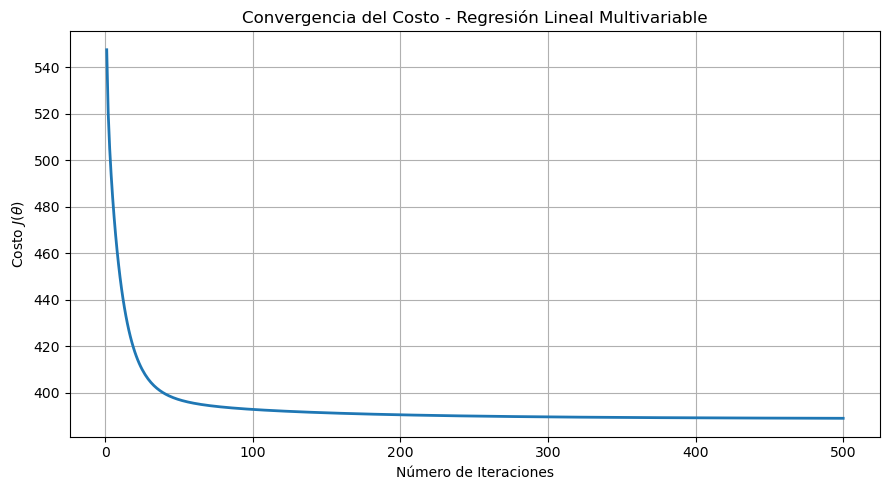

       MODELO 1 - REGRESIÓN LINEAL MULTIVARIABLE
Costo inicial       : 621.8717
Costo final         : 388.9393
Reducción del costo : 37.46%
Theta 0             : 7.1086

Primeros 10 parámetros theta:
[ 7.1086 -1.2179 -0.7362 -0.6028 -0.1039 -0.6949  0.6122  0.3985  0.0991
  1.6673]


In [11]:
# ==============================================================================
# MODELO 1 - REGRESIÓN LINEAL MULTIVARIABLE
# ==============================================================================

alpha_lin = 0.03

# Empezamos con 500; luego observamos la convergencia
num_iters_lin = 500


theta_inicial_lin = np.zeros(
    X_train_lin.shape[1]
)


theta_lin, J_history_lin = gradientDescentMulti(
    X_train_lin,
    y_train,
    theta_inicial_lin,
    alpha_lin,
    num_iters_lin
)


# ==============================================================================
# GRÁFICA DE CONVERGENCIA
# ==============================================================================

pyplot.figure(figsize=(9, 5))

pyplot.plot(
    np.arange(1, len(J_history_lin) + 1),
    J_history_lin,
    lw=2
)

pyplot.xlabel(
    'Número de Iteraciones'
)

pyplot.ylabel(
    r'Costo $J(\theta)$'
)

pyplot.title(
    'Convergencia del Costo - '
    'Regresión Lineal Multivariable'
)

pyplot.grid(True)

pyplot.tight_layout()

pyplot.show()


# ==============================================================================
# RESULTADOS
# ==============================================================================

print("=" * 70)
print("       MODELO 1 - REGRESIÓN LINEAL MULTIVARIABLE")
print("=" * 70)

print(
    f"Costo inicial       : "
    f"{costo_inicial_lin:.4f}"
)

print(
    f"Costo final         : "
    f"{J_history_lin[-1]:.4f}"
)

reduccion_lin = (
    (costo_inicial_lin - J_history_lin[-1])
    / costo_inicial_lin
) * 100

print(
    f"Reducción del costo : "
    f"{reduccion_lin:.2f}%"
)

print(
    f"Theta 0             : "
    f"{theta_lin[0]:.4f}"
)

print("\nPrimeros 10 parámetros theta:")
print(
    np.round(
        theta_lin[:10],
        4
    )
)

print("=" * 70)

In [12]:
# ==============================================================================
# MÉTRICAS DE EVALUACIÓN
# ==============================================================================

def metricasRegresion(y_real, y_pred):

    # Error absoluto medio
    mae = np.mean(
        np.abs(y_real - y_pred)
    )

    # Error cuadrático medio
    mse = np.mean(
        (y_real - y_pred) ** 2
    )

    # Raíz del error cuadrático medio
    rmse = np.sqrt(mse)

    # R cuadrado
    ss_res = np.sum(
        (y_real - y_pred) ** 2
    )

    ss_tot = np.sum(
        (y_real - np.mean(y_real)) ** 2
    )

    r2 = 1 - (
        ss_res / ss_tot
    )

    return mae, mse, rmse, r2


print("Función de métricas definida correctamente.")

Función de métricas definida correctamente.


In [13]:
# ==============================================================================
# VALIDACIÓN DEL MODELO 1
# ==============================================================================

pred_train_lin = np.dot(
    X_train_lin,
    theta_lin
)

pred_val_lin = np.dot(
    X_val_lin,
    theta_lin
)


costo_train_lin = computeCostMulti(
    X_train_lin,
    y_train,
    theta_lin
)

costo_val_lin = computeCostMulti(
    X_val_lin,
    y_val,
    theta_lin
)


mae_lin, mse_lin, rmse_lin, r2_lin = metricasRegresion(
    y_val,
    pred_val_lin
)


print("=" * 70)
print("       VALIDACIÓN - MODELO LINEAL")
print("=" * 70)

print(
    f"Costo entrenamiento : "
    f"{costo_train_lin:.4f}"
)

print(
    f"Costo validación     : "
    f"{costo_val_lin:.4f}"
)

print("-" * 70)

print(f"MAE  : {mae_lin:.4f}")
print(f"MSE  : {mse_lin:.4f}")
print(f"RMSE : {rmse_lin:.4f}")
print(f"R²   : {r2_lin:.4f}")

print("=" * 70)

       VALIDACIÓN - MODELO LINEAL
Costo entrenamiento : 388.9393
Costo validación     : 732.9856
----------------------------------------------------------------------
MAE  : 9.2454
MSE  : 1465.9713
RMSE : 38.2880
R²   : 0.0390


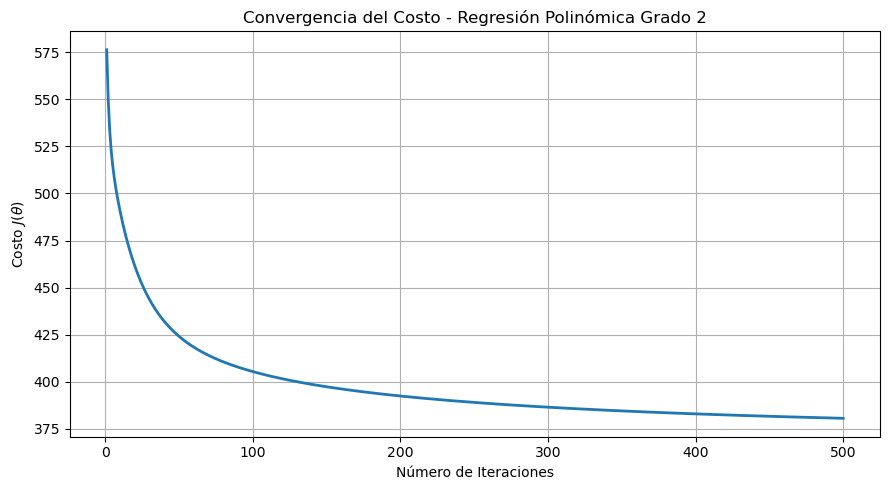

       MODELO 2 - REGRESIÓN POLINÓMICA
Costo inicial : 621.8717
Costo final   : 380.6147
Reducción del costo : 38.80%

Primeros 10 parámetros theta:
[ 7.0619  0.0723 -0.5048 -0.0522  0.1116 -0.528   0.2587  0.3717 -0.0165
  0.7097]


In [14]:
# ==============================================================================
# MODELO 2 - REGRESIÓN POLINÓMICA GRADO 2
# ==============================================================================

alpha_poly = 0.01

num_iters_poly = 500


theta_inicial_poly = np.zeros(
    X_train_poly.shape[1]
)


theta_poly, J_history_poly = gradientDescentMulti(
    X_train_poly,
    y_train,
    theta_inicial_poly,
    alpha_poly,
    num_iters_poly
)


# ==============================================================================
# GRÁFICA DE COSTO
# ==============================================================================

pyplot.figure(figsize=(9, 5))

pyplot.plot(
    np.arange(1, len(J_history_poly) + 1),
    J_history_poly,
    lw=2
)

pyplot.xlabel(
    'Número de Iteraciones'
)

pyplot.ylabel(
    r'Costo $J(\theta)$'
)

pyplot.title(
    'Convergencia del Costo - '
    'Regresión Polinómica Grado 2'
)

pyplot.grid(True)

pyplot.tight_layout()

pyplot.show()


# ==============================================================================
# RESULTADOS
# ==============================================================================

print("=" * 70)
print("       MODELO 2 - REGRESIÓN POLINÓMICA")
print("=" * 70)

print(
    f"Costo inicial : "
    f"{costo_inicial_poly:.4f}"
)

print(
    f"Costo final   : "
    f"{J_history_poly[-1]:.4f}"
)

reduccion_poly = (
    (costo_inicial_poly - J_history_poly[-1])
    / costo_inicial_poly
) * 100

print(
    f"Reducción del costo : "
    f"{reduccion_poly:.2f}%"
)

print("\nPrimeros 10 parámetros theta:")
print(
    np.round(
        theta_poly[:10],
        4
    )
)

print("=" * 70)

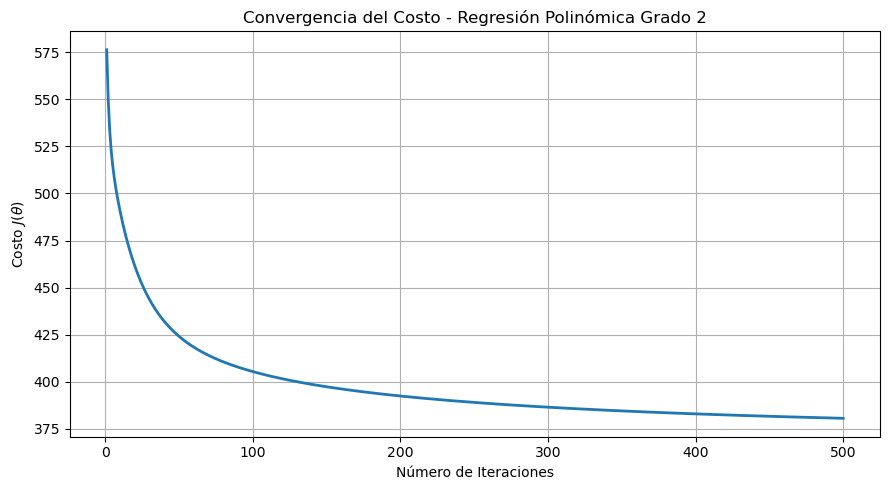

       MODELO 2 - REGRESIÓN POLINÓMICA
Costo inicial : 621.8717
Costo final   : 380.6147
Reducción del costo : 38.80%

Primeros 10 parámetros theta:
[ 7.0619  0.0723 -0.5048 -0.0522  0.1116 -0.528   0.2587  0.3717 -0.0165
  0.7097]


In [15]:
# ==============================================================================
# MODELO 2 - REGRESIÓN POLINÓMICA GRADO 2
# ==============================================================================

alpha_poly = 0.01

num_iters_poly = 500


theta_inicial_poly = np.zeros(
    X_train_poly.shape[1]
)


theta_poly, J_history_poly = gradientDescentMulti(
    X_train_poly,
    y_train,
    theta_inicial_poly,
    alpha_poly,
    num_iters_poly
)


# ==============================================================================
# GRÁFICA DE COSTO
# ==============================================================================

pyplot.figure(figsize=(9, 5))

pyplot.plot(
    np.arange(1, len(J_history_poly) + 1),
    J_history_poly,
    lw=2
)

pyplot.xlabel(
    'Número de Iteraciones'
)

pyplot.ylabel(
    r'Costo $J(\theta)$'
)

pyplot.title(
    'Convergencia del Costo - '
    'Regresión Polinómica Grado 2'
)

pyplot.grid(True)

pyplot.tight_layout()

pyplot.show()


# ==============================================================================
# RESULTADOS
# ==============================================================================

print("=" * 70)
print("       MODELO 2 - REGRESIÓN POLINÓMICA")
print("=" * 70)

print(
    f"Costo inicial : "
    f"{costo_inicial_poly:.4f}"
)

print(
    f"Costo final   : "
    f"{J_history_poly[-1]:.4f}"
)

reduccion_poly = (
    (costo_inicial_poly - J_history_poly[-1])
    / costo_inicial_poly
) * 100

print(
    f"Reducción del costo : "
    f"{reduccion_poly:.2f}%"
)

print("\nPrimeros 10 parámetros theta:")
print(
    np.round(
        theta_poly[:10],
        4
    )
)

print("=" * 70)

In [16]:
# ==============================================================================
# MODELO 3 - ECUACIÓN NORMAL
# ==============================================================================

def normalEqn(X, y):
    """
    Obtiene los parámetros theta mediante la pseudoinversa
    de Moore-Penrose.
    """

    theta = np.dot(
        np.linalg.pinv(X),
        y
    )

    return theta


# ==============================================================================
# CÁLCULO DE THETA
# ==============================================================================

# IMPORTANTE:
# La ecuación normal se aplica a las mismas características
# del modelo lineal multivariable.

theta_normal = normalEqn(
    X_train_lin,
    y_train
)


# ==============================================================================
# PREDICCIONES
# ==============================================================================

pred_train_normal = np.dot(
    X_train_lin,
    theta_normal
)

pred_val_normal = np.dot(
    X_val_lin,
    theta_normal
)


# ==============================================================================
# COSTOS
# ==============================================================================

costo_train_normal = computeCostMulti(
    X_train_lin,
    y_train,
    theta_normal
)

costo_val_normal = computeCostMulti(
    X_val_lin,
    y_val,
    theta_normal
)


# ==============================================================================
# MÉTRICAS
# ==============================================================================

mae_normal, mse_normal, rmse_normal, r2_normal = metricasRegresion(
    y_val,
    pred_val_normal
)


print("=" * 75)
print("       MODELO 3 - ECUACIÓN NORMAL")
print("=" * 75)

print(f"Costo entrenamiento : {costo_train_normal:.4f}")
print(f"Costo validación     : {costo_val_normal:.4f}")

print("-" * 75)

print(f"MAE  : {mae_normal:.4f}")
print(f"MSE  : {mse_normal:.4f}")
print(f"RMSE : {rmse_normal:.4f}")
print(f"R²   : {r2_normal:.4f}")

print("-" * 75)

print("Dimensión de theta:", theta_normal.shape)

print("=" * 75)

       MODELO 3 - ECUACIÓN NORMAL
Costo entrenamiento : 386.4459
Costo validación     : 735.9868
---------------------------------------------------------------------------
MAE  : 9.3177
MSE  : 1471.9735
RMSE : 38.3663
R²   : 0.0350
---------------------------------------------------------------------------
Dimensión de theta: (54,)


In [17]:
# ==============================================================================
# COMPARACIÓN: DESCENSO POR GRADIENTE VS ECUACIÓN NORMAL
# ==============================================================================

# Calcular qué tan diferentes son las predicciones
# generadas por ambos métodos sobre validación.
diferencia_predicciones = np.sqrt(
    np.mean(
        (pred_val_lin - pred_val_normal) ** 2
    )
)

print("=" * 75)
print("    COMPARACIÓN: DESCENSO POR GRADIENTE VS ECUACIÓN NORMAL")
print("=" * 75)

print(
    f"RMSE entre las predicciones de ambos métodos : "
    f"{diferencia_predicciones:.4f}"
)

print("-" * 75)

print(
    f"Costo de validación - Descenso por Gradiente : "
    f"{costo_val_lin:.4f}"
)

print(
    f"Costo de validación - Ecuación Normal        : "
    f"{costo_val_normal:.4f}"
)

print("-" * 75)

print(
    f"R² - Descenso por Gradiente : "
    f"{r2_lin:.4f}"
)

print(
    f"R² - Ecuación Normal        : "
    f"{r2_normal:.4f}"
)

print("=" * 75)

    COMPARACIÓN: DESCENSO POR GRADIENTE VS ECUACIÓN NORMAL
RMSE entre las predicciones de ambos métodos : 2.3752
---------------------------------------------------------------------------
Costo de validación - Descenso por Gradiente : 732.9856
Costo de validación - Ecuación Normal        : 735.9868
---------------------------------------------------------------------------
R² - Descenso por Gradiente : 0.0390
R² - Ecuación Normal        : 0.0350


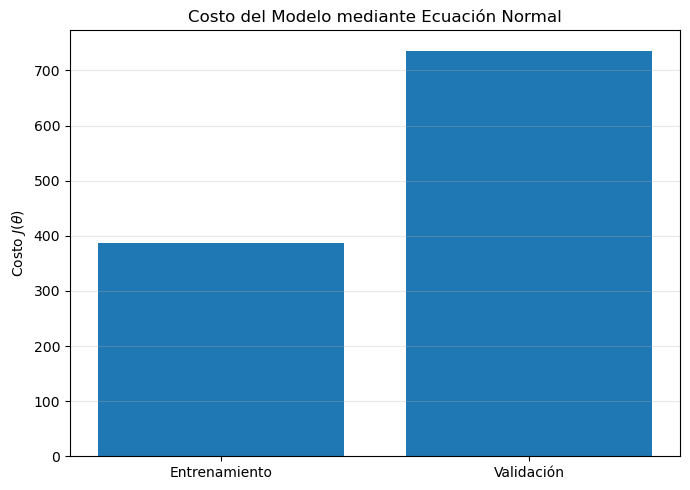

In [18]:
# ==============================================================================
# GRÁFICA DE COSTO - ECUACIÓN NORMAL
# ==============================================================================

pyplot.figure(figsize=(7, 5))

pyplot.bar(
    ['Entrenamiento', 'Validación'],
    [
        costo_train_normal,
        costo_val_normal
    ]
)

pyplot.ylabel(
    r'Costo $J(\theta)$'
)

pyplot.title(
    'Costo del Modelo mediante Ecuación Normal'
)

pyplot.grid(
    axis='y',
    alpha=0.3
)

pyplot.tight_layout()

pyplot.show()

In [19]:
# ==============================================================================
# VALIDACIÓN DEL MODELO 2 - REGRESIÓN POLINÓMICA
# ==============================================================================

# Predicciones sobre entrenamiento
pred_train_poly = np.dot(
    X_train_poly,
    theta_poly
)

# Predicciones sobre validación
pred_val_poly = np.dot(
    X_val_poly,
    theta_poly
)

# Costos
costo_train_poly = computeCostMulti(
    X_train_poly,
    y_train,
    theta_poly
)

costo_val_poly = computeCostMulti(
    X_val_poly,
    y_val,
    theta_poly
)

# Métricas
mae_poly, mse_poly, rmse_poly, r2_poly = metricasRegresion(
    y_val,
    pred_val_poly
)

print("=" * 70)
print("       VALIDACIÓN - MODELO POLINÓMICO")
print("=" * 70)

print(f"Costo entrenamiento : {costo_train_poly:.4f}")
print(f"Costo validación     : {costo_val_poly:.4f}")

print("-" * 70)

print(f"MAE  : {mae_poly:.4f}")
print(f"MSE  : {mse_poly:.4f}")
print(f"RMSE : {rmse_poly:.4f}")
print(f"R²   : {r2_poly:.4f}")

print("-" * 70)

print("pred_train_poly:", pred_train_poly.shape)
print("pred_val_poly  :", pred_val_poly.shape)

print("=" * 70)

       VALIDACIÓN - MODELO POLINÓMICO
Costo entrenamiento : 380.6147
Costo validación     : 922.9975
----------------------------------------------------------------------
MAE  : 8.9669
MSE  : 1845.9950
RMSE : 42.9650
R²   : -0.2102
----------------------------------------------------------------------
pred_train_poly: (32759,)
pred_val_poly  : (8190,)


In [20]:
print("Predicciones disponibles:")
print("Lineal          :", pred_val_lin.shape)
print("Polinómica      :", pred_val_poly.shape)
print("Ecuación Normal :", pred_val_normal.shape)
print("Valores reales  :", y_val.shape)

Predicciones disponibles:
Lineal          : (8190,)
Polinómica      : (8190,)
Ecuación Normal : (8190,)
Valores reales  : (8190,)


In [21]:
# ==============================================================================
# 100 PREDICCIONES SOBRE EL CONJUNTO DE VALIDACIÓN
# ==============================================================================

cantidad_predicciones = 100

tabla_predicciones = pd.DataFrame({

    'Valor Real':
        y_val[:cantidad_predicciones],

    'Regresión Lineal':
        pred_val_lin[:cantidad_predicciones],

    'Regresión Polinómica':
        pred_val_poly[:cantidad_predicciones],

    'Ecuación Normal':
        pred_val_normal[:cantidad_predicciones]

})

print("=" * 90)
print("       PRIMERAS 100 PREDICCIONES DEL CONJUNTO DE VALIDACIÓN")
print("=" * 90)

display(tabla_predicciones.round(2))

       PRIMERAS 100 PREDICCIONES DEL CONJUNTO DE VALIDACIÓN


,Valor Real,Regresión Lineal,Regresión Polinómica,Ecuación Normal
0,0.0,-2.90,-2.52,-2.28
1,1.0,2.35,1.61,3.03
2,0.0,-2.48,-2.53,-2.70
3,7.0,8.12,8.85,7.14
4,0.0,1.39,0.61,1.45
...,...,...,...,...
95,0.0,-4.77,-4.07,-4.55
96,1.0,9.93,9.66,9.42
97,4.0,10.64,10.13,10.60
98,0.0,-0.02,-0.02,-0.45


In [22]:
# ==============================================================================
# COMPARACIÓN DE LOS TRES MODELOS
# ==============================================================================

resultados = pd.DataFrame({

    'Modelo': [
        'Regresión Lineal Multivariable',
        'Regresión Polinómica Grado 2',
        'Ecuación Normal'
    ],

    'Costo Entrenamiento': [
        costo_train_lin,
        costo_train_poly,
        costo_train_normal
    ],

    'Costo Validación': [
        costo_val_lin,
        costo_val_poly,
        costo_val_normal
    ],

    'MAE': [
        mae_lin,
        mae_poly,
        mae_normal
    ],

    'RMSE': [
        rmse_lin,
        rmse_poly,
        rmse_normal
    ],

    'R2': [
        r2_lin,
        r2_poly,
        r2_normal
    ]
})

print("=" * 100)
print("                    COMPARACIÓN DE LOS TRES MODELOS")
print("=" * 100)

display(resultados.round(4))

                    COMPARACIÓN DE LOS TRES MODELOS


,Modelo,Costo Entrenamiento,Costo Validación,MAE,RMSE,R2
0,Regresión Lineal Multivariable,388.9393,732.9856,9.2454,38.2880,0.0390
1,Regresión Polinómica Grado 2,380.6147,922.9975,8.9669,42.9650,-0.2102
2,Ecuación Normal,386.4459,735.9868,9.3177,38.3663,0.0350
